In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Configuración visual para gráficos estilo "publicación académica"
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "serif"
})

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


In [ ]:
# Carga directa desde el archivo generado por el benchmark
csv_filename = "benchmark_granular_workflow.csv"

try:
    df = pd.read_csv(csv_filename)
    print(f"✅ Archivo '{csv_filename}' cargado exitosamente.")
    print(f"📊 Total de registros analizados: {len(df)}")
    
    # Separar los perfiles en Python y C++ para análisis específicos
    df_py = df[df['perfil'].isin(['seq', 'par', 'weights'])].copy()
    df_cpp = df[df['perfil'].str.startswith('cpp_')].copy()
    
    # Mostrar un resumen de los datos cargados
    display(df.head())
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{csv_filename}'.")
    print("Asegúrate de que el notebook esté en la misma carpeta que el CSV o ajusta la ruta.")

✅ Archivo 'benchmark_granular_workflow.csv' cargado exitosamente.
📊 Total de registros analizados: 600


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,10,seq,0.989457,0.001538,3.622739,4.613735,209.242188,10.401367,568.765625,568.765625,42,100,1280
1,1,10,par,1.800524,0.138371,2.676230,4.615125,573.167969,52.151367,2530.167969,2530.167969,42,100,1280
2,1,10,weights,0.828238,0.062673,1.886640,2.777551,204.665039,38.908203,1298.651367,1298.651367,42,100,1280
3,1,10,cpp_seq,0.007326,0.000110,0.057034,0.064512,58.515625,2.062500,161.968750,222.546875,42,100,1280
4,1,10,cpp_par,0.018569,0.000061,0.141179,0.175058,62.109375,2.046875,160.484375,224.640625,42,100,1280


In [ ]:
# Verificamos que para cada 'sample', el número de atractores, pares y campos sea idéntico en todos los perfiles
integrity_check = df.groupby('sample')[['n_attractors', 'n_pairs', 'n_fields']].nunique()

is_consistent = (integrity_check == 1).all().all()

if is_consistent:
    print("✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.")
else:
    print("❌ ADVERTENCIA: Hay discrepancias en los resultados topológicos entre los perfiles.")
    display(integrity_check[integrity_check > 1].dropna())

✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.


In [ ]:
# Cell 11: Speedup and Average Execution Time Analysis (Python vs C++)
import pandas as pd

# Calculate average execution times for each profile (robust against multiple samples)
t_py_seq = df.loc[df['perfil'] == 'seq', 'total_t'].mean()
t_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'total_t'].mean()

t_py_par = df.loc[df['perfil'] == 'par', 'total_t'].mean()
t_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'total_t'].mean()

# In Python the advanced parallel profile is 'weights', in C++ it is 'cpp_adv'
t_py_adv = df.loc[df['perfil'] == 'weights', 'total_t'].mean()
t_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'total_t'].mean()

# Speedup calculations (avoiding division by zero if any data is missing)
speedup_seq = (t_py_seq / t_cpp_seq) if t_cpp_seq > 0 else 0
speedup_par = (t_py_par / t_cpp_par) if t_cpp_par > 0 else 0
speedup_adv = (t_py_adv / t_cpp_adv) if t_cpp_adv > 0 else 0

print("=== 🚀 SPEEDUP ANALYSIS (PYTHON VS C++) ===")

print("\n--- 1. Sequential Comparison (Single Thread) ---")
print(f"⏱️ Python 'seq':     {t_py_seq:.6f} s")
print(f"⏱️ C++ 'cpp_seq':    {t_cpp_seq:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_seq:.2f}x faster")

print("\n--- 2. Parallel Comparison (Standard) ---")
print(f"⏱️ Python 'par':     {t_py_par:.6f} s")
print(f"⏱️ C++ 'cpp_par':    {t_cpp_par:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_par:.2f}x faster")

print(f"\n--- 3. Advanced Comparison (CBN-specific) ---")
print(f"⏱️ Python 'weights':  {t_py_adv:.6f} s")
print(f"⏱️ C++ 'cpp_adv':     {t_cpp_adv:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_adv:.2f}x faster")

=== 🚀 SPEEDUP ANALYSIS (PYTHON VS C++) ===

--- 1. Sequential Comparison (Single Thread) ---
⏱️ Python 'seq':     4.617035 s
⏱️ C++ 'cpp_seq':    0.091394 s
🔥 Speedup:          C++ is 50.52x faster

--- 2. Parallel Comparison (Standard) ---
⏱️ Python 'par':     2.463272 s
⏱️ C++ 'cpp_par':    0.081088 s
🔥 Speedup:          C++ is 30.38x faster

--- 3. Advanced Comparison (CBN-specific) ---
⏱️ Python 'weights':  2.375531 s
⏱️ C++ 'cpp_adv':     0.079888 s
🔥 Speedup:          C++ is 29.74x faster


In [ ]:
# Cell 12: Generate LaTeX Table Code for the Paper
latex_table_code = f"""
\\begin{{table}}[htbp]
    \\centering
    \\caption{{Performance execution time comparison and speedup between Python and C++ implementations.}}
    \\label{{tab:cbn_performance_speedup}}
    \\begin{{tabular}}{{lrrr}}
        \\hline
        \\textbf{{Execution Strategy}} & \\textbf{{Python (s)}} & \\textbf{{C++ (s)}} & \\textbf{{Speedup}} \\\\ \\hline
        Sequential & {t_py_seq:.4f} & {t_cpp_seq:.4f} & \\textbf{{{speedup_seq:.1f}×}} \\\\
        Parallel   & {t_py_par:.4f} & {t_cpp_par:.4f} & \\textbf{{{speedup_par:.1f}×}} \\\\
        Advanced   & {t_py_adv:.4f} & {t_cpp_adv:.4f} & \\textbf{{{speedup_adv:.1f}×}} \\\\ \\hline
    \\end{{tabular}}
\\end{{table}}
"""

print("=== 📄 GENERATED LATEX TABLE CODE ===")
print(latex_table_code)

# Optional: Automatically save it to a .tex snippet file for LuaLaTeX `\\input{{}}` inclusion
with open("table_performance_speedup.tex", "w") as f:
    f.write(latex_table_code)
print("\n✅ Table successfully exported to 'table_performance_speedup.tex'!")

=== 📄 GENERATED LATEX TABLE CODE ===

\begin{table}[htbp]
    \centering
    \caption{Performance execution time comparison and speedup between Python and C++ implementations.}
    \label{tab:cbn_performance_speedup}
    \begin{tabular}{lrrr}
        \hline
        \textbf{Execution Strategy} & \textbf{Python (s)} & \textbf{C++ (s)} & \textbf{Speedup} \\ \hline
        Sequential & 4.6170 & 0.0914 & \textbf{50.5×} \\
        Parallel   & 2.4633 & 0.0811 & \textbf{30.4×} \\
        Advanced   & 2.3755 & 0.0799 & \textbf{29.7×} \\ \hline
    \end{tabular}
\end{table}


✅ Table successfully exported to 'table_performance_speedup.tex'!


In [ ]:
# Cell 13: Memory Efficiency Analysis (Python vs C++)
import pandas as pd

# Calculate average total memory consumption (mem_total_kb) for each profile
mem_py_seq = df.loc[df['perfil'] == 'seq', 'mem_total_kb'].mean()
mem_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'mem_total_kb'].mean()

mem_py_par = df.loc[df['perfil'] == 'par', 'mem_total_kb'].mean()
mem_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'mem_total_kb'].mean()

mem_py_adv = df.loc[df['perfil'] == 'weights', 'mem_total_kb'].mean()
mem_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'mem_total_kb'].mean()

# Overhead calculations. Handling division by zero for safety.
overhead_seq = (mem_py_seq / mem_cpp_seq) if mem_cpp_seq > 0 else float('inf')
overhead_par = (mem_py_par / mem_cpp_par) if mem_cpp_par > 0 else float('inf')
overhead_adv = (mem_py_adv / mem_cpp_adv) if mem_cpp_adv > 0 else float('inf')

print("=== 🧠 MEMORY EFFICIENCY ANALYSIS (PYTHON VS C++) ===")
print("Metric: Overhead Factor (How many times more memory Python requires)")

print("\n--- 1. Sequential Comparison (Single Thread) ---")
print(f"📦 Python 'seq':      {mem_py_seq:.2f} KB")
print(f"📦 C++ 'cpp_seq':     {mem_cpp_seq:.2f} KB")
if mem_cpp_seq > 0:
    print(f"📉 Overhead:        Python consumes {overhead_seq:.2f}x more memory")
else:
    print("📉 Overhead:        N/A (C++ reports 0 KB)")

print("\n--- 2. Parallel Comparison (Standard) ---")
print(f"📦 Python 'par':      {mem_py_par:.2f} KB")
print(f"📦 C++ 'cpp_par':     {mem_cpp_par:.2f} KB")
if mem_cpp_par > 0:
    print(f"📉 Overhead:        Python consumes {overhead_par:.2f}x more memory")

print("\n--- 3. Advanced Comparison (CBN-specific) ---")
print(f"📦 Python 'weights':  {mem_py_adv:.2f} KB")
print(f"📦 C++ 'cpp_adv':     {mem_cpp_adv:.2f} KB")
if mem_cpp_adv > 0:
    print(f"📉 Overhead:        Python consumes {overhead_adv:.2f}x more memory")

# Parallelism Memory Penalty Analysis
print("\n--- ⚠️ MEMORY PENALTY FOR MULTIPROCESSING ---")
penalidad_py = (mem_py_par / mem_py_seq) if mem_py_seq > 0 else 0
penalidad_cpp = (mem_cpp_par / mem_cpp_seq) if mem_cpp_seq > 0 else 0
print(f"When switching from Sequential to Parallel:")
print(f"🐍 Python inflates its memory by: {penalidad_py:.2f}x")
print(f"⚙️ C++ inflates its memory by:    {penalidad_cpp:.2f}x")

=== 🧠 MEMORY EFFICIENCY ANALYSIS (PYTHON VS C++) ===
Metric: Overhead Factor (How many times more memory Python requires)

--- 1. Sequential Comparison (Single Thread) ---
📦 Python 'seq':      764.93 KB
📦 C++ 'cpp_seq':     261.28 KB
📉 Overhead:        Python consumes 2.93x more memory

--- 2. Parallel Comparison (Standard) ---
📦 Python 'par':      2584.36 KB
📦 C++ 'cpp_par':     260.00 KB
📉 Overhead:        Python consumes 9.94x more memory

--- 3. Advanced Comparison (CBN-specific) ---
📦 Python 'weights':  1758.14 KB
📦 C++ 'cpp_adv':     220.48 KB
📉 Overhead:        Python consumes 7.97x more memory

--- ⚠️ MEMORY PENALTY FOR MULTIPROCESSING ---
When switching from Sequential to Parallel:
🐍 Python inflates its memory by: 3.38x
⚙️ C++ inflates its memory by:    1.00x


In [ ]:
# Cell 14: Generate LaTeX Memory Table Code for the Paper
latex_memory_table_code = f"""
\\begin{{table}}[htbp]
    \\centering
    \\caption{{Peak memory consumption (KB) and overhead factor comparison between Python and C++ implementations.}}
    \\label{{tab:cbn_memory_overhead}}
    \\begin{{tabular}}{{lrrr}}
        \\hline
        \\textbf{{Execution Strategy}} & \\textbf{{Python (KB)}} & \\textbf{{C++ (KB)}} & \\textbf{{Overhead}} \\\\ \\hline
        Sequential & {mem_py_seq:.2f} & {mem_cpp_seq:.2f} & \\textbf{{{overhead_seq:.1f}×}} \\\\
        Parallel   & {mem_py_par:.2f} & {mem_cpp_par:.2f} & \\textbf{{{overhead_par:.1f}×}} \\\\
        Advanced   & {mem_py_adv:.2f} & {mem_cpp_adv:.2f} & \\textbf{{{overhead_adv:.1f}×}} \\\\ \\hline
    \\end{{tabular}}
\\end{{table}}
"""

print("=== 📄 GENERATED LATEX MEMORY TABLE CODE ===")
print(latex_memory_table_code)

# Export snippet file for LuaLaTeX `\\input{{}}` inclusion
with open("table_memory_overhead.tex", "w") as f:
    f.write(latex_memory_table_code)
print("\n✅ Memory table successfully exported to 'table_memory_overhead.tex'!")

=== 📄 GENERATED LATEX MEMORY TABLE CODE ===

\begin{table}[htbp]
    \centering
    \caption{Peak memory consumption (KB) and overhead factor comparison between Python and C++ implementations.}
    \label{tab:cbn_memory_overhead}
    \begin{tabular}{lrrr}
        \hline
        \textbf{Execution Strategy} & \textbf{Python (KB)} & \textbf{C++ (KB)} & \textbf{Overhead} \\ \hline
        Sequential & 764.93 & 261.28 & \textbf{2.9×} \\
        Parallel   & 2584.36 & 260.00 & \textbf{9.9×} \\
        Advanced   & 1758.14 & 220.48 & \textbf{8.0×} \\ \hline
    \end{tabular}
\end{table}


✅ Memory table successfully exported to 'table_memory_overhead.tex'!


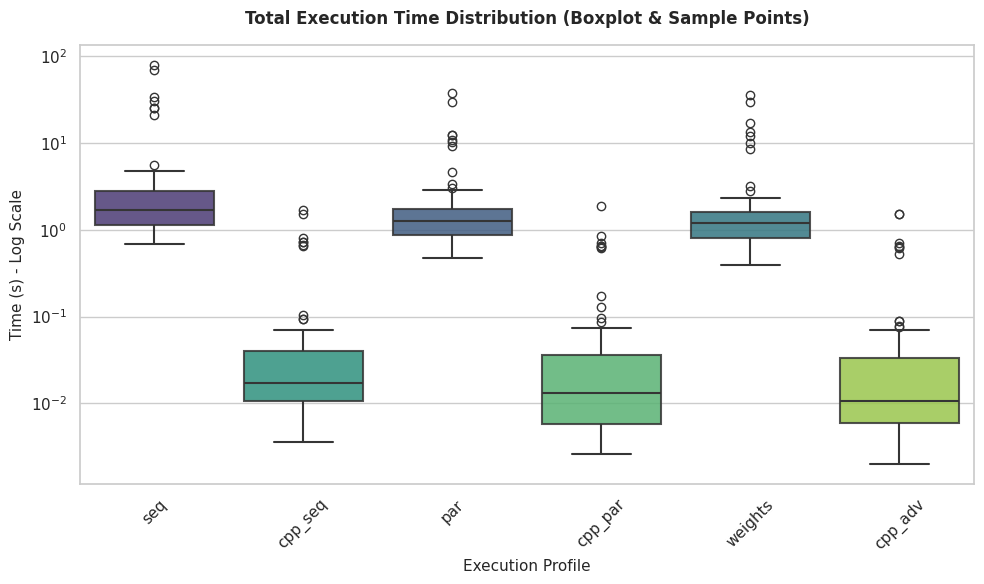

In [ ]:
# Cell 7: Modernized Total Execution Time Distribution (Boxplot with Stripplot Overlay)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Ensure visual order: Python followed by C++ implementation for each strategy
profile_order = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

# Modern boxplot syntax (fixing palette/hue deprecation warning)
sns.boxplot(
    data=df, 
    x='perfil', 
    y='total_t', 
    order=profile_order, 
    hue='perfil',
    palette='viridis',
    legend=False,
    ax=ax,
    boxprops=dict(alpha=0.85),
    linewidth=1.5
)

ax.set_title('Total Execution Time Distribution (Boxplot & Sample Points)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Time (s) - Log Scale', fontsize=11)
ax.set_xlabel('Execution Profile', fontsize=11)
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# Vectorial export for the academic paper
plt.tight_layout()
plt.savefig("boxplot_execution_time.pdf", format='pdf', bbox_inches='tight')
plt.show()

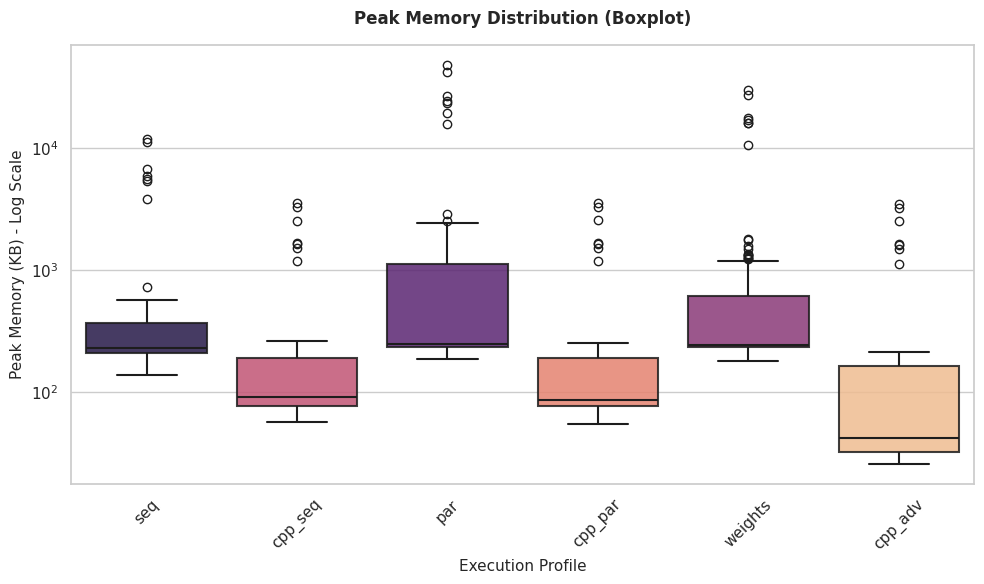

In [ ]:
# Cell 8: Peak Memory Distribution (Python vs C++ Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Ensure visual order: Python (higher footprint) followed by C++ implementation for each strategy
profile_order = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

# Modern boxplot syntax (fixing palette/hue deprecation warning)
sns.boxplot(
    data=df, 
    x='perfil', 
    y='mem_total_kb', 
    order=profile_order, 
    hue='perfil',
    palette='magma',
    legend=False,
    ax=ax,
    boxprops=dict(alpha=0.85),
    linewidth=1.5
)

ax.set_title('Peak Memory Distribution (Boxplot)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Peak Memory (KB) - Log Scale', fontsize=11)
ax.set_xlabel('Execution Profile', fontsize=11)
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# Vectorial export for the academic paper
plt.tight_layout()
plt.savefig("boxplot_peak_memory.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Analisis by step

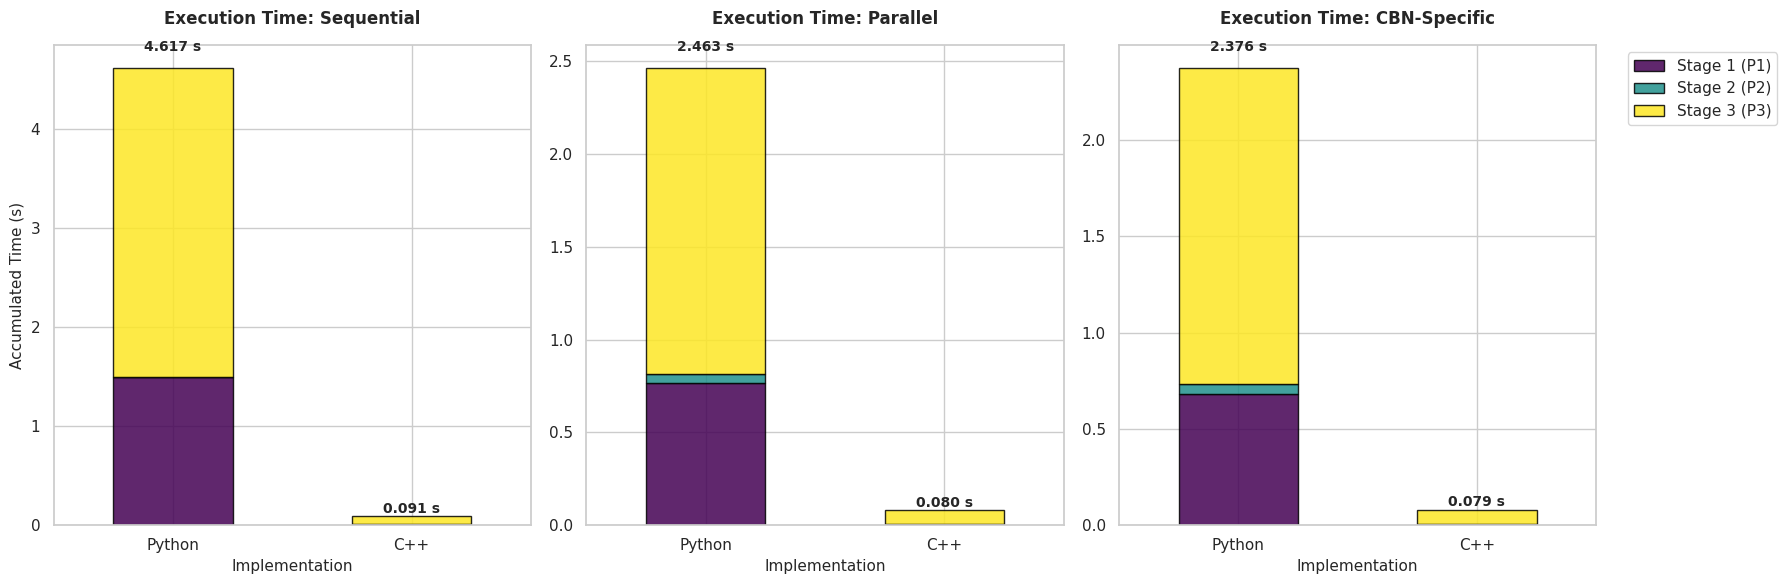

In [ ]:
# Cell: Cumulative Stacked Execution Time Breakdown by Stage (Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Exact columns from your dataframe
time_cols = ['t_p1', 't_p2', 't_p3']

# Define exact comparative pairs (Python first, C++ second)
comparative_pairs = [
    ('Sequential', ['seq', 'cpp_seq']),
    ('Parallel', ['par', 'cpp_par']),
    ('CBN-Specific', ['weights', 'cpp_adv'])
]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (title, profiles) in enumerate(comparative_pairs):
    # Filter data for the current comparison round
    df_par = df[df['perfil'].isin(profiles)].copy()
    
    # Group by profile and average time stages
    df_mean = df_par.groupby('perfil')[time_cols].mean().reset_index()
    
    # Create language column to structure the chart clearly
    df_mean['Language'] = df_mean['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # SORT: Python first (left), then C++ (right)
    df_mean = df_mean.sort_values(by='Language', ascending=False).set_index('Language')
    
    # Plot stacked bars using 'crest' colormap for a professional academic look
    df_mean[time_cols].plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='black', alpha=0.85
    )
    
    axes[i].set_title(f"Execution Time: {title}", fontweight='bold', pad=15, fontsize=12)
    axes[i].set_xlabel("Implementation", fontsize=11)
    axes[i].tick_params(axis='x', rotation=0)
    
    if i == 0:
        axes[i].set_ylabel("Accumulated Time (s)", fontsize=11)
    else:
        axes[i].set_ylabel("")
        
    # Add precise total value label on top of each stacked bar
    for j, (idx, row) in enumerate(df_mean.iterrows()):
        total_stacked = row[time_cols].sum()
        axes[i].text(j, total_stacked + (total_stacked * 0.03), f"{total_stacked:.3f} s", 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Show legend only on the rightmost plot to avoid cluttering
    if i == 2:
        axes[i].legend(["Stage 1 (P1)", "Stage 2 (P2)", "Stage 3 (P3)"], 
                       loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True)
    else:
        axes[i].legend().remove()

# Adjust margins to prevent clipping upon export
plt.tight_layout()
plt.savefig("time_stacked_python_vs_cpp.pdf", format='pdf', bbox_inches='tight')
plt.show()

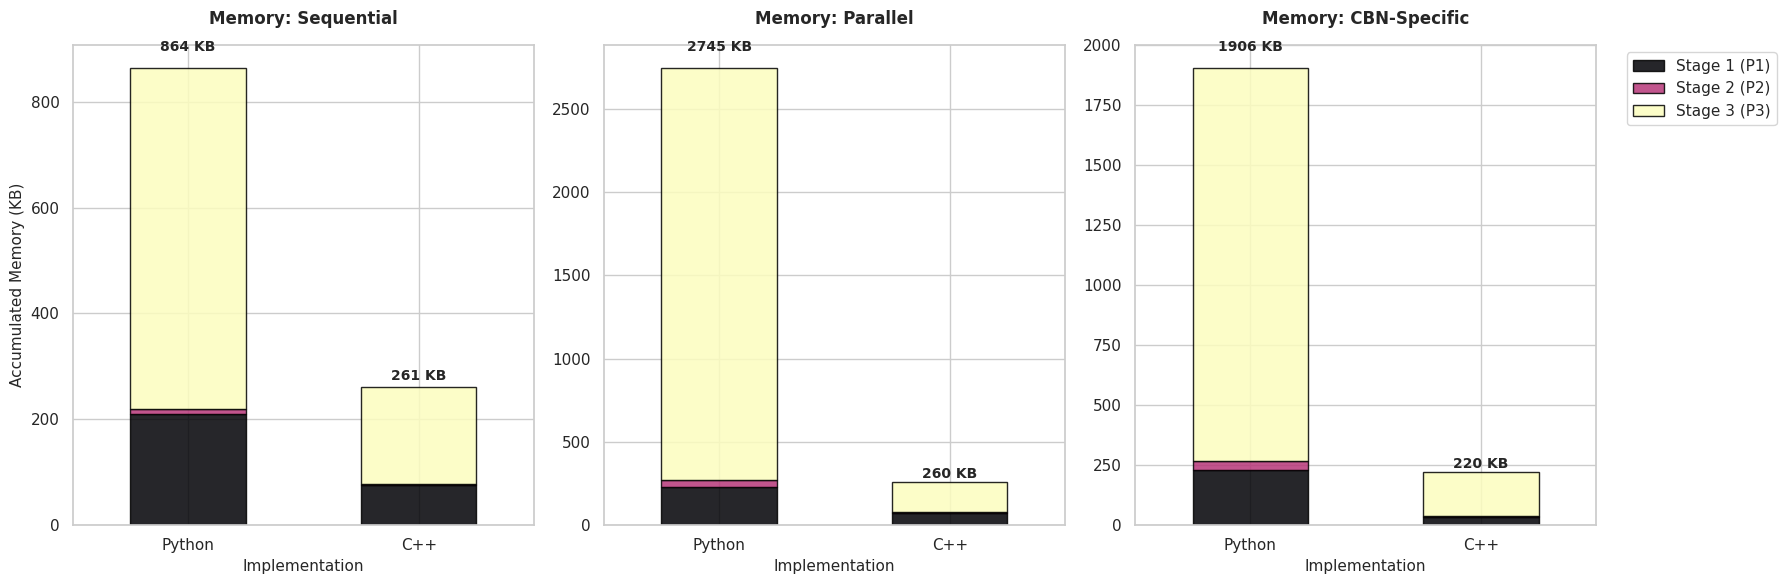

In [ ]:
# Cell 6: Cumulative Stacked Memory Breakdown Comparison (Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Define exact comparative pairs (Python first, C++ second)
comparative_pairs = [
    ('Sequential', ['seq', 'cpp_seq']),
    ('Parallel', ['par', 'cpp_par']),
    ('CBN-Specific', ['weights', 'cpp_adv'])
]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (title, profiles) in enumerate(comparative_pairs):
    # Filter data for the current comparison round
    df_par = df[df['perfil'].isin(profiles)].copy()
    
    # Group by profile and average memory stages
    df_mean = df_par.groupby('perfil')[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].mean().reset_index()
    
    # Create language column to structure the chart clearly
    df_mean['Language'] = df_mean['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # SORT: Python first (left), then C++ (right)
    # ascending=False ensures 'Python' comes before 'C++' alphabetically
    df_mean = df_mean.sort_values(by='Language', ascending=False).set_index('Language')
    
    # Plot stacked bars using 'magma' colormap for high-contrast academic printing
    df_mean[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].plot(
        kind='bar', stacked=True, ax=axes[i], colormap='magma', edgecolor='black', alpha=0.85
    )
    
    axes[i].set_title(f"Memory: {title}", fontweight='bold', pad=15, fontsize=12)
    axes[i].set_xlabel("Implementation", fontsize=11)
    axes[i].tick_params(axis='x', rotation=0)
    
    if i == 0:
        axes[i].set_ylabel("Accumulated Memory (KB)", fontsize=11)
    else:
        axes[i].set_ylabel("")
        
    # Add total value label on top of each stacked bar for precise reporting
    for j, (idx, row) in enumerate(df_mean.iterrows()):
        total_stacked = row['mem_p1_kb'] + row['mem_p2_kb'] + row['mem_p3_kb']
        axes[i].text(j, total_stacked + (total_stacked * 0.03), f"{total_stacked:.0f} KB", 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Show legend only on the rightmost plot to avoid cluttering the visual area
    if i == 2:
        axes[i].legend(["Stage 1 (P1)", "Stage 2 (P2)", "Stage 3 (P3)"], 
                       loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True)
    else:
        axes[i].legend().remove()

# Adjust margins to prevent text or legend clipping upon export
plt.tight_layout()
plt.savefig("memory_stacked_python_vs_cpp.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Celda 8: Análisis Estadístico Descriptivo

print("=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===")
# Agrupamos por perfil y calculamos métricas clave
time_stats = df.groupby('perfil')['total_t'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos de más lento a más rápido
time_stats = time_stats.sort_values(by='Media', ascending=False)
display(time_stats.style.format("{:.6f}", na_rep="-").background_gradient(cmap='Blues'))

print("\n=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===")
mem_stats = df.groupby('perfil')['mem_total_kb'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos del que consume más memoria al que menos
mem_stats = mem_stats.sort_values(by='Media', ascending=False)
display(mem_stats.style.format("{:.2f}", na_rep="-").background_gradient(cmap='Reds'))

# Exportar las estadísticas descriptivas directamente a un archivo LaTeX para Overleaf
time_stats.to_latex("table_times_summary.tex", float_format="%.4f")
mem_stats.to_latex("table_memory_summary.tex", float_format="%.2f")

=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
seq,100.000000,4.617035,11.562818,1.701286,0.685240,79.883109
par,100.000000,2.463272,5.082185,1.268864,0.472758,37.983364
weights,100.000000,2.375531,5.089719,1.187435,0.390250,36.014979
cpp_seq,100.000000,0.091394,0.265222,0.017104,0.003590,1.676064
cpp_par,100.000000,0.081088,0.242630,0.013013,0.002577,1.870802
cpp_adv,100.000000,0.079888,0.246559,0.010566,0.002015,1.522082



=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
par,100.00,2584.36,7705.85,246.48,188.44,47795.38
weights,100.00,1758.14,5076.54,245.59,179.36,29590.27
seq,100.00,764.93,1926.80,232.18,139.40,11834.59
cpp_seq,100.00,261.28,581.02,91.37,57.64,3516.64
cpp_par,100.00,260.00,580.28,87.20,55.20,3510.59
cpp_adv,100.00,220.48,580.51,42.13,26.03,3452.34


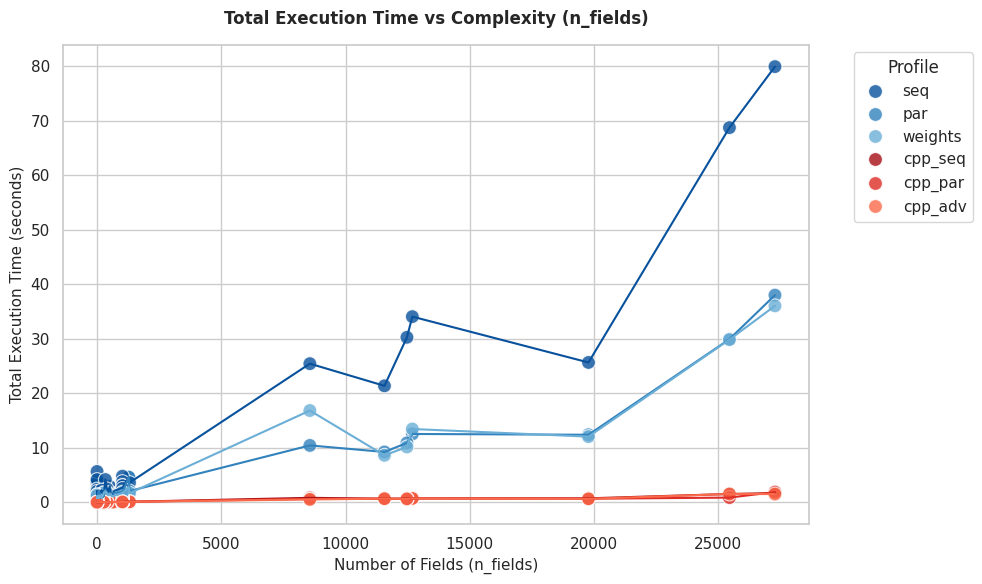

In [ ]:
# Cell 10a: Complexity Relationship (n_fields) vs Total Time (total_t)
import matplotlib.pyplot as plt
import seaborn as sns

# Unified palette: Blues for Python, Reds for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=df, x='n_fields', y='total_t', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)

# Clean trend lines (errorbar=None avoids cluttered confidence intervals)
sns.lineplot(
    data=df, x='n_fields', y='total_t', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Total Execution Time vs Complexity (n_fields)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Total Execution Time (seconds)', fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=11)

# Clean sidebar legend
plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Vector export for LuaLaTeX
plt.tight_layout()
plt.savefig("complexity_vs_total_time.pdf", format='pdf', bbox_inches='tight')
plt.show()

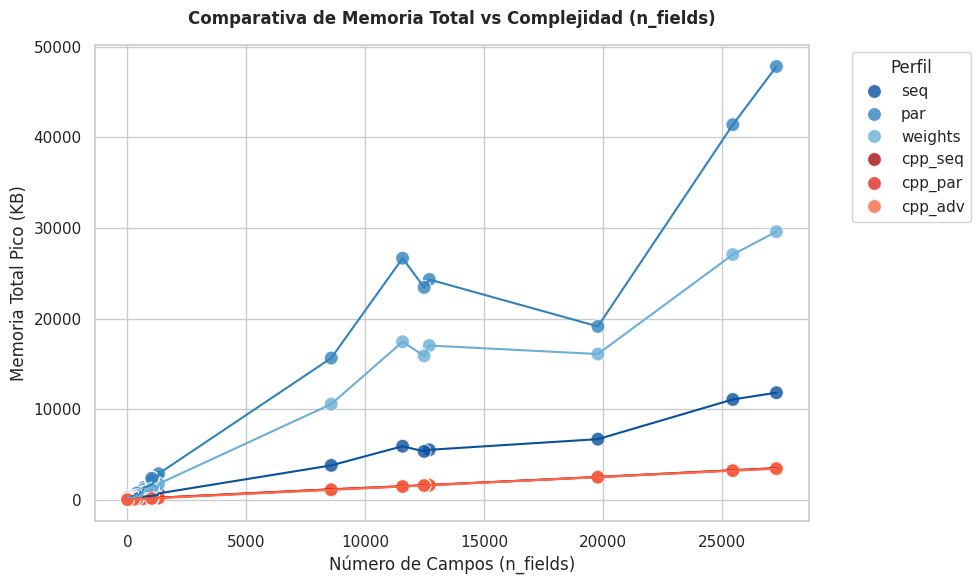

In [ ]:
# Celda 10b: Relación de Complejidad (n_fields) vs Memoria Total (mem_total_kb)
import matplotlib.pyplot as plt
import seaborn as sns

paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Memoria Total vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Memoria Total Pico (KB)')
ax.set_xlabel('Número de Campos (n_fields)')

plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("complejidad_vs_memoria_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Especific Analisis Step 3

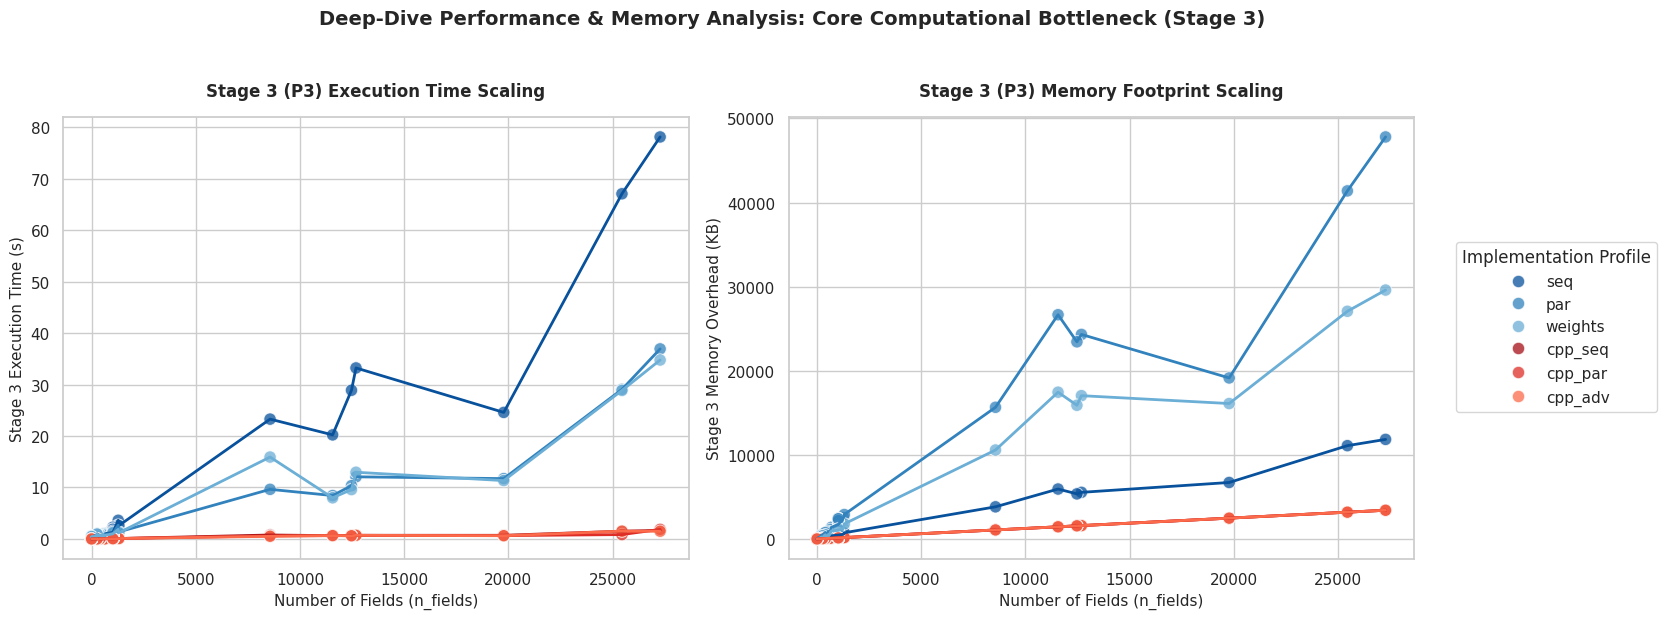

In [ ]:
# Cell: Megaplot - Stage 3 (P3) Deep Dive: Time and Memory Scaling vs. Complexity
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Unified custom palette: Blues for Python, Reds for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

# Create a figure with 2 subplots side-by-side (1 row, 2 columns) with adjusted width for the legend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Step 3 Execution Time vs n_fields ---
sns.scatterplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, s=80, alpha=0.75, ax=axes[0], legend=True
)
sns.lineplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, linewidth=2, ax=axes[0]
)
axes[0].set_title('Stage 3 (P3) Execution Time Scaling', fontweight='bold', pad=15, fontsize=12)
axes[0].set_xlabel('Number of Fields (n_fields)', fontsize=11)
axes[0].set_ylabel('Stage 3 Execution Time (s)', fontsize=11)

# --- Panel 2: Step 3 Memory Overhead vs n_fields ---
sns.scatterplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, s=80, alpha=0.75, ax=axes[1], legend=False
)
sns.lineplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, linewidth=2, ax=axes[1]
)
axes[1].set_title('Stage 3 (P3) Memory Footprint Scaling', fontweight='bold', pad=15, fontsize=12)
axes[1].set_xlabel('Number of Fields (n_fields)', fontsize=11)
axes[1].set_ylabel('Stage 3 Memory Overhead (KB)', fontsize=11)

# Extract handles and labels from the first axis to build a clean unified legend
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove() # Remove individual legend

# Position a professional unified legend on the right side
fig.legend(handles, labels, title='Implementation Profile', loc='center left', bbox_to_anchor=(0.91, 0.5), frameon=True)

# Main title for the entire megagraphics canvas
plt.suptitle('Deep-Dive Performance & Memory Analysis: Core Computational Bottleneck (Stage 3)', fontsize=14, fontweight='bold', y=1.03)

# Vector export for LaTeX / Overleaf with extra margin for the external legend
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig("megaplot_stage3_deep_dive.pdf", format='pdf', bbox_inches='tight')
plt.show()

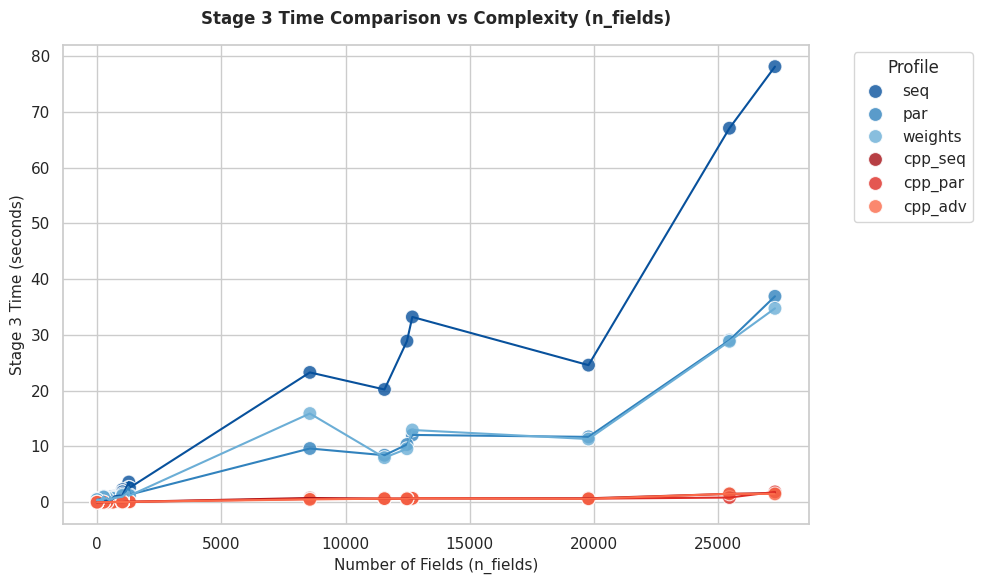

In [ ]:
# Cell 9a: Complexity vs Time Relationship in Stage 3 (P3)
import matplotlib.pyplot as plt
import seaborn as sns

# Custom palette: Blues for Python, Reds/Oranges for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot and trend lines
sns.scatterplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Stage 3 Time Comparison vs Complexity (n_fields)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Stage 3 Time (seconds)', fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=11)

# Logarithmic scale crucial to see the C++ trend without flattening
# ax.set_yscale('log') 

# Adjust legend outside the plot
plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("complexity_vs_time_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

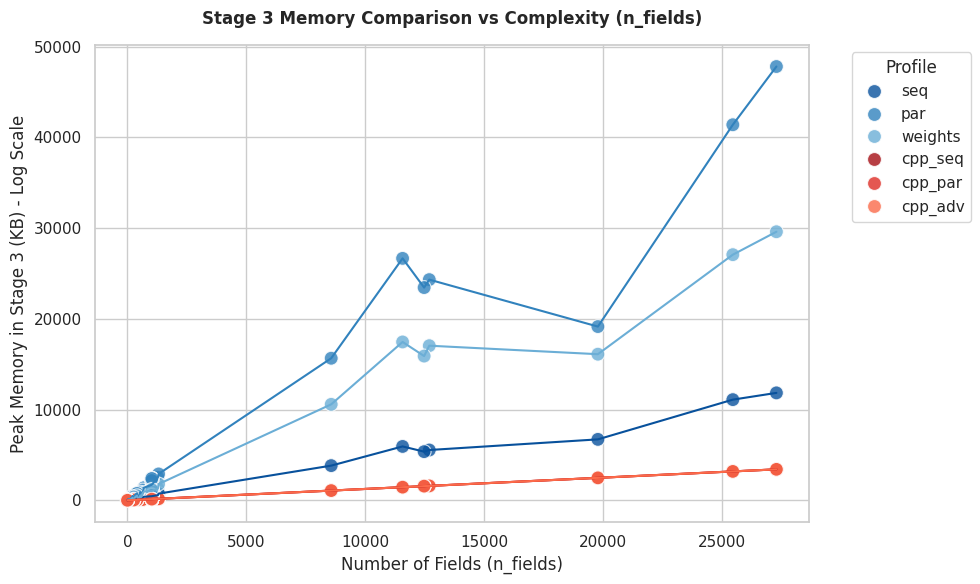


=== 📈 (PEARSON) CORRELATION WITH n_fields IN STAGE 3 ===

🐍 PYTHON:
  • Correlation n_fields vs Time P3:   0.8841
  • Correlation n_fields vs Memory P3: 0.8776

⚙️ C++:
  • Correlation n_fields vs Time P3:   0.9690
  • Correlation n_fields vs Memory P3: 1.0000


In [ ]:
# Cell 9b: Complexity vs Memory Relationship in Stage 3 (P3) and Correlation
import matplotlib.pyplot as plt
import seaborn as sns

# We use the same palette to maintain visual consistency
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Stage 3 Memory Comparison vs Complexity (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Peak Memory in Stage 3 (KB) - Log Scale')
ax.set_xlabel('Number of Fields (n_fields)')
#ax.set_yscale('log')

plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("complexity_vs_memory_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

# --- CORRELATION ANALYSIS ---
print("\n=== 📈 (PEARSON) CORRELATION WITH n_fields IN STAGE 3 ===")

print("\n🐍 PYTHON:")
# Use the filtered Python DataFrame (df_py) to isolate metrics
if df_py['n_fields'].nunique() > 1:
    corr_py_t = df_py['n_fields'].corr(df_py['t_p3'])
    corr_py_m = df_py['n_fields'].corr(df_py['mem_p3_kb'])
    print(f"  • Correlation n_fields vs Time P3:   {corr_py_t:.4f}")
    print(f"  • Correlation n_fields vs Memory P3: {corr_py_m:.4f}")
else:
    print("  • Run the benchmark with multiple topologies to calculate correlation.")

print("\n⚙️ C++:")
# Use the filtered C++ DataFrame (df_cpp)
if df_cpp['n_fields'].nunique() > 1:
    corr_cpp_t = df_cpp['n_fields'].corr(df_cpp['t_p3'])
    corr_cpp_m = df_cpp['n_fields'].corr(df_cpp['mem_p3_kb'])
    print(f"  • Correlation n_fields vs Time P3:   {corr_cpp_t:.4f}")
    print(f"  • Correlation n_fields vs Memory P3: {corr_cpp_m:.4f}")
else:
    print("  • Run the benchmark with multiple topologies to calculate correlation.")

In [ ]:
df.describe()

,sample,n_nets,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
count,600.000000,600.0,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000
mean,50.500000,10.0,0.495466,0.016790,1.105502,1.618035,142.968208,15.224491,884.725431,974.864993,31.080000,49.33000,1463.400000
std,28.890155,0.0,0.675405,0.025367,5.635151,5.794294,85.658042,17.248482,3974.797106,3957.491984,10.407407,41.88825,4606.702618
min,1.000000,10.0,0.001917,0.000040,0.000016,0.002015,24.421875,0.703125,0.000000,26.031250,20.000000,0.00000,0.000000
25%,25.750000,10.0,0.007255,0.000062,0.000297,0.013819,66.593750,1.468750,1.164062,84.968750,21.000000,16.00000,0.000000
50%,50.500000,10.0,0.194119,0.000772,0.024375,0.625600,123.502929,4.969238,40.473633,212.390625,33.000000,37.50000,4.500000
75%,75.250000,10.0,0.798650,0.037625,0.438916,1.353840,229.390380,37.940674,156.512451,251.721436,42.000000,80.00000,1024.000000
max,100.000000,10.0,5.642407,0.162187,78.090359,79.883109,573.167969,52.151367,47795.380859,47795.380859,54.000000,158.00000,27280.000000
